In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Forward
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def tanh(Z):
    return np.tanh(Z)

def forward(X, W1, b1, W2, b2):
    Z1 = W1 @ X + b1
    A1 = tanh(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)
    return A2


In [8]:
# Dummy trained params
np.random.seed(0)
W1 = np.random.randn(2, 2)
b1 = np.zeros((2, 1))
W2 = np.random.randn(1, 2)
b2 = np.zeros((1, 1))

In [9]:
# Wrapper
def model_wrapper(X_input):
    X_input = X_input.T
    A2 = forward(X_input, W1, b1, W2, b2)
    return (A2 > 0.5).astype(int).flatten()

In [10]:
# Plot function
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.show()

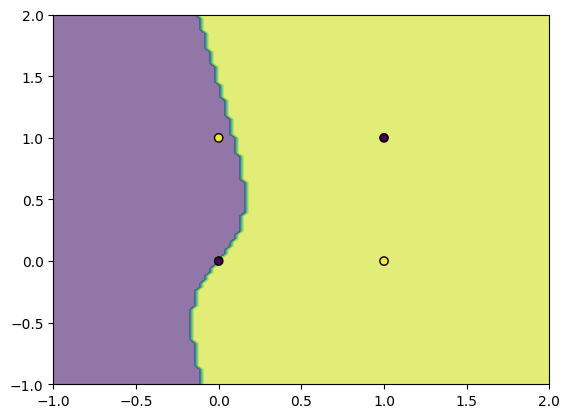

In [11]:
# XOR data
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

plot_decision_boundary(model_wrapper, X, y)